In [1]:
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
import polars as pl
import alphalens as al
import matplotlib.pyplot as plt
from datetime import datetime

# 配置文件
try:
    import config_local as config
except ImportError:
    import config

# 导入数据接口sdk
import zenidatasdk as zd
client = zd.Client(
    base_url=config.ZENI_URL,
    username=config.ZENI_USERNAME,
    password=config.ZENI_PASSWORD,
)

# 忽视警告信息
warnings.filterwarnings(action='ignore')

In [2]:
# 历史回测区间
init_date = '2025-11-01'
start_date = '2025-12-01'
end_date = str(datetime.today().date())
index_symbol = rf"000852.XSHG"

# rf"000300.XSHG",  # 沪深300
# rf"000905.XSHG",  # 中证500
# rf"000852.XSHG",  # 中证1000
# rf"000016.XSHG",  # 上证50
# rf"399006.XSHE",  # 创业板

In [3]:
# 获取指数成分股数据据
index_weights_df = client.get_index_constituents_df(
    index_symbol=index_symbol,
    start_date=start_date,
    end_date=end_date
)
index_weights_df = index_weights_df.rename(columns={"date": "datetime"})
symbols = index_weights_df["symbol"].unique().tolist()
index_weights_df

,datetime,index_symbol,update_date,symbol,weight,display_name
0,2025-12-01,000852.XSHG,2025-11-28,000012.XSHE,0.069,南玻A
1,2025-12-01,000852.XSHG,2025-11-28,000019.XSHE,0.030,深粮控股
2,2025-12-01,000852.XSHG,2025-11-28,000025.XSHE,0.050,特力A
3,2025-12-01,000852.XSHG,2025-11-28,000028.XSHE,0.061,国药一致
4,2025-12-01,000852.XSHG,2025-11-28,000029.XSHE,0.083,深深房A
...,...,...,...,...,...,...
95995,2026-04-24,000852.XSHG,2026-03-31,688776.XSHG,0.055,国光电气
95996,2026-04-24,000852.XSHG,2026-03-31,688779.XSHG,0.143,五矿新能
95997,2026-04-24,000852.XSHG,2026-03-31,688789.XSHG,0.084,宏华数科
95998,2026-04-24,000852.XSHG,2026-03-31,688798.XSHG,0.073,艾为电子


In [4]:
# ================ 定义本地分钟数据路径 ================
tmp_Dataset_path = rf"D:\tmp_Dataset"
minute_bar_Dataset_path = os.path.join(tmp_Dataset_path, "minute_bar")  # 分钟数据本地路径
os.makedirs(minute_bar_Dataset_path, exist_ok=True)

index_weights_path = os.path.join(minute_bar_Dataset_path, index_symbol)  # 指数成分股
os.makedirs(index_weights_path, exist_ok=True)


# ================ 按月获取分钟数据 ================
def generate_monthly_ranges_dict(start_date, end_date):
    """生成按月切割的日期区间字典，格式为 {YYMM: (月初, 月末)}"""
    start = datetime.strptime(start_date, '%Y-%m-%d').date()
    end = datetime.strptime(end_date, '%Y-%m-%d').date()

    date_dict = {}
    current = start

    import calendar
    while True:
        month_start = current.replace(day=1)
        _, last_day = calendar.monthrange(current.year, current.month)
        month_end = current.replace(day=last_day)

        if month_end > end:  # 不足一个月舍弃
            break

        # 键格式：YYMM（如 2603 表示 2026年03月）
        key = f"{str(current.year)[-2:]}{current.month:02d}"
        date_dict[key] = (month_start.strftime('%Y-%m-%d'), month_end.strftime('%Y-%m-%d'))

        # 移到下个月
        if current.month == 12:
            current = current.replace(year=current.year + 1, month=1, day=1)
        else:
            current = current.replace(month=current.month + 1, day=1)

    return date_dict

date_tuple_list = generate_monthly_ranges_dict(init_date, end_date)
date_tuple_list

{'2511': ('2025-11-01', '2025-11-30'),
 '2512': ('2025-12-01', '2025-12-31'),
 '2601': ('2026-01-01', '2026-01-31'),
 '2602': ('2026-02-01', '2026-02-28'),
 '2603': ('2026-03-01', '2026-03-31')}

In [5]:
def tmp_filter(dataframe):
    # 1. 临时转换为 datetime 用于过滤
    # 2. 过滤后删除临时列，保留原始字符串
    return (
        dataframe
        .filter(
            (pl.col("datetime").dt.time() <= pl.time(10, 0, 0)) |
            (pl.col("datetime").dt.time() == pl.time(15, 0, 0))
        )
    )
tmp_filter = None


from tqdm import tqdm
big_minute_bar_dict = {}
for month, start_end_tuple in tqdm(
    date_tuple_list.items(), desc = "获取每月分钟数据"
):

    minute_bar_monthly_path = os.path.join(index_weights_path, rf"{month}.parquet")
    if os.path.exists(minute_bar_monthly_path):
        bars_1m_df_tmp = pd.read_parquet(minute_bar_monthly_path)
    else:
        bars_1m_df_tmp = client.get_kline_df(
            symbol = symbols,
            start_date = start_end_tuple[0],
            end_date = start_end_tuple[1],
            frequency = "1m",
            adjust_type = "post",
            market = "cn_stock",
        )
        bars_1m_df_tmp.to_parquet(minute_bar_monthly_path, engine = 'pyarrow',compression = 'snappy')

    # 删除部分数据，减少内存负担 tmp_filter
    if tmp_filter:
        big_minute_bar_dict[month] = tmp_filter(bars_1m_df_tmp)
    else:
        big_minute_bar_dict[month] = bars_1m_df_tmp
    import gc; gc.collect()


# 分钟数据长表格 bars_1m_df
bars_1m_df = pd.concat(list(big_minute_bar_dict.values()))
bars_1m_df.head()

获取每月分钟数据: 100%|██████████| 5/5 [00:03<00:00,  1.49it/s]


,open,high,low,close,volume,symbol,amount,datetime
0,652.72,652.72,641.36,641.36,46146.83,000006.XSHE,29887897.0,2025-11-03 09:31:00
1,641.36,641.88,635.17,635.17,35893.05,000006.XSHE,22902399.0,2025-11-03 09:32:00
2,632.58,635.17,619.67,622.77,54638.38,000006.XSHE,34146136.0,2025-11-03 09:33:00
3,621.74,623.81,615.03,622.77,61855.72,000006.XSHE,38316132.0,2025-11-03 09:34:00
4,622.77,630.00,622.77,623.29,45381.91,000006.XSHE,28385346.0,2025-11-03 09:35:00


In [6]:
import gc; gc.collect()

15

In [10]:
# 获取日频估值数据
fundamental_1d_df = client.get_valuation_df(
    symbols=symbols,
    start_date=start_date,
    end_date=end_date,
    fields="datetime,symbol,market_cap,circulating_market_cap,turnover_ratio,pe_ratio,pb_ratio,dividend_ratio"
)

# 构建市值数据
mkt_cap_name = "market_cap"
market_cap_df = fundamental_1d_df.set_index(["datetime", "symbol"])[[mkt_cap_name]]

# 负数和无穷值 & 对数处理
market_cap_df[mkt_cap_name] = np.where((market_cap_df[mkt_cap_name] <= 0) | (~np.isfinite(market_cap_df[mkt_cap_name])),
                                       0, market_cap_df[mkt_cap_name])
market_cap_df[f"{mkt_cap_name}_log"] = np.log1p(market_cap_df[mkt_cap_name])
market_cap = market_cap_df[f"{mkt_cap_name}_log"]
market_cap.head()

datetime    symbol     
2025-12-01  000012.XSHE    4.985274
            000019.XSHE    4.425104
            000025.XSHE    4.458403
            000028.XSHE    4.946219
            000029.XSHE    5.509942
Name: market_cap_log, dtype: float64

In [9]:
# 获取行业数据
industry_constituents_df = client.get_industry_constituents_composite_df(
    symbols = symbols,
    category = "sw_l1",
    start_date = start_date,
    end_date = end_date
)

# 构建双重索引的行业数据
industries = industry_constituents_df.set_index(["datetime", "symbol"])["industry_name"]
industries

datetime    symbol     
2025-12-01  000019.XSHE    农林牧渔I
            000048.XSHE    农林牧渔I
            000735.XSHE    农林牧渔I
            000930.XSHE    农林牧渔I
            002041.XSHE    农林牧渔I
                           ...  
2026-04-24  600223.XSHG    美容护理I
            600315.XSHG    美容护理I
            603193.XSHG    美容护理I
            603983.XSHG    美容护理I
            605009.XSHG    美容护理I
Name: industry_name, Length: 106877, dtype: object

In [11]:
prices_df = bars_1m_df[bars_1m_df['datetime'] >= start_date].copy()
prices_df = bars_1m_df.rename(columns = {'datetime': 'datetime_min'})
prices_df['datetime'] = prices_df['datetime_min'].dt.normalize()

prices_df = prices_df.groupby(['datetime', "symbol"]).agg(open = ('open', 'first')).reset_index()
prices = prices_df.pivot(index = 'datetime', columns = 'symbol', values = 'open')
prices.head()

symbol,000006.XSHE,000010.XSHE,000011.XSHE,000012.XSHE,000016.XSHE,000019.XSHE,000025.XSHE,000028.XSHE,000029.XSHE,000030.XSHE,...,688733.XSHG,688739.XSHG,688766.XSHG,688776.XSHG,688778.XSHG,688779.XSHG,688788.XSHG,688789.XSHG,688798.XSHG,688800.XSHG
datetime,,,,,,,,,,,,,,,,,,,,,
2025-11-03,652.72,50.78,50.22,173.89,132.01,44.65,49.85,144.43,68.54,23.87,...,27.66,30.61,528.94,128.62,142.37,7.40,139.43,182.36,116.41,141.35
2025-11-04,637.75,53.57,48.93,174.25,133.47,44.71,50.10,144.15,67.90,24.00,...,28.22,30.65,615.28,130.71,138.52,7.21,148.57,177.84,116.79,148.81
2025-11-05,599.53,51.58,47.46,174.25,132.49,44.97,49.44,143.18,67.09,23.66,...,31.17,30.72,565.81,128.08,131.64,7.02,143.82,170.06,112.74,134.71
2025-11-06,622.77,52.51,48.15,176.81,134.20,45.29,49.58,144.09,69.16,24.00,...,32.70,30.69,613.22,135.86,140.73,7.39,147.94,170.57,116.79,135.15
2025-11-07,621.22,51.31,47.04,177.18,133.22,45.74,49.91,144.09,68.61,24.25,...,33.63,30.64,594.64,139.40,147.69,7.41,142.21,172.00,113.89,134.67


In [77]:
def f_1228(bars: pd.DataFrame, f_name: str = 'Average_relative_price_position', cal_range: int = 1, roll_days: int = 20) -> pd.DataFrame:
    """
    factor_intro: 衡量股票在价格相对高位停留的时间长短
    category: 高频因子
    category_intro: 收益率分布类
    subcategory:
    subcategory_intro:
    min_period: 20d
    source: 朱剑涛, 2020, 基于时间维度度量的日内买卖压力, 东方证券
    author: 因子团队

    说明：使用每日K线的典型价格（(开盘+收盘+最高+最低)/4）计算日内时间加权平均价格（TWAP），
    并在过去 cal_range 个交易日内按交易时长加权平均，再对过去 roll_days 个交易日做滚动平滑，
    作为原始因子值。根据以上计算过程，判断因子方向为正向。
    因子逻辑：股票在价格相对高位停留的时间越长，表明买方压力越大，未来收益越高；
    通过度量价格在相对高位停留的时间长短，捕捉买方压力较大的股票。

    Parameters
    ----------
    bars: pd.DataFrame
        分钟频 bars
        ['datetime', 'symbol', 'open', 'high', 'low', 'close']
    f_name: str
        因子名称，默认为 'Average_relative_price_position'
    cal_range: int
        时间窗口天数，默认为 1。研报原文分别基于1日、5日、20日三个时间窗口
        滚动计算指标，本实现采用过去 cal_range 日滚动加权平均替代。
    roll_days: int
        滚动平滑天数，默认为 20。研报原文做20个交易日的平滑得到最终因子，
        本实现采用过去 roll_days 日滚动均值替代。

    Returns
    -------
    factors: pd.DataFrame
        日频 factors
        ['datetime', 'symbol', 'factor_name', 'factor_value']
    """
    # pass
    # bars = bars_1m_df.copy()
    # f_name = 'Average_relative_price_position'
    # cal_range = 1
    # roll_days = 20


    # 分离时间轴 分钟与天
    bars = bars.rename(columns = {'datetime': 'datetime_min'})
    bars['datetime'] = bars['datetime_min'].dt.normalize()

    # 计算每个分钟 K 线的 TWAP
    bars['TWAP_min'] = (bars['open'] + bars['high'] + bars['low'] + bars['close']) / 4

    #   计算每日逐个分钟 TWAP 的加总值
    bars = bars.groupby(['symbol', 'datetime']).agg(
        TWAP_day_sum = ('TWAP_min', 'sum'),
        num_of_day_Kline = ('TWAP_min', 'count'),
    )

    # 按日滚动，计算区间内的多日 TWAP
    bars = bars.sort_index(level = ['datetime', 'symbol'])
    bars['TWAP_range_sum'] = (
        bars
        .groupby('symbol')['TWAP_day_sum']
        .rolling(window = cal_range)
        .sum()
        .reset_index(level = 0, drop = True)
    )
    bars['num_of_range_Kline'] = (
        bars
        .groupby('symbol')['num_of_day_Kline']
        .rolling(window = cal_range)
        .sum()
        .reset_index(level = 0, drop = True)
    )
    bars['TWAP_range'] = bars['TWAP_range_sum'] / bars['num_of_range_Kline']

    # 计算滚动窗口平滑的 多日 TWAP
    bars['factor_value'] = (
        bars
        .groupby('symbol')['TWAP_range']
        .rolling(window = roll_days)
        .mean()
        .reset_index(level = 0, drop = True)
    )


    bars['factor_name'] = f_name
    bars = bars.reset_index()
    return bars[['datetime', 'symbol', 'factor_name', 'factor_value']]

In [82]:
# 计算因子数据
factors_df = f_1228(
    bars = bars_1m_df,
    f_name = 'Average_relative_price_position',
    cal_range = 3,
    roll_days = 20
)
factors_df

,datetime,symbol,factor_name,factor_value
0,2025-11-03,000006.XSHE,Average_relative_price_position,NaN
1,2025-11-03,000010.XSHE,Average_relative_price_position,NaN
2,2025-11-03,000011.XSHE,Average_relative_price_position,NaN
3,2025-11-03,000012.XSHE,Average_relative_price_position,NaN
4,2025-11-03,000016.XSHE,Average_relative_price_position,NaN
...,...,...,...,...
224924,2026-03-31,688779.XSHG,Average_relative_price_position,11.523006
224925,2026-03-31,688788.XSHG,Average_relative_price_position,125.548575
224926,2026-03-31,688789.XSHG,Average_relative_price_position,168.694189
224927,2026-03-31,688798.XSHG,Average_relative_price_position,99.894725


In [83]:
# 因子值 shift 1 转换成实际使用时间(T+1)
factors_df['factor_value'] = factors_df.groupby(['symbol'])['factor_value'].transform(lambda x: x.shift(1))

# 与指数的交易日历、历史成分股数据对齐
factor_df= pd.merge(left = index_weights_df[['datetime', 'symbol']], right = factors_df, how = 'left', on = ['datetime', 'symbol'])



# 转换成[datetime, symbol]双重索引的factors
factors = factor_df.pivot_table(index = ['datetime', 'symbol'], columns = 'factor_name', values = 'factor_value')
factors.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 77000 entries, (Timestamp('2025-12-03 00:00:00'), '000012.XSHE') to (Timestamp('2026-03-31 00:00:00'), '688800.XSHG')
Data columns (total 1 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Average_relative_price_position  77000 non-null  float64
dtypes: float64(1)
memory usage: 836.5+ KB


In [84]:
# 调用alphalens进行数据清洗
factor_data = al.utils.get_clean_factor_and_forward_returns(
    factor=factors,
    prices=prices,
    periods=(1, 5, 20),
    bins=None,
    quantiles=7,
    groupby=None,
    groupby_labels=None,
    binning_by_group=False,
    filter_zscore=20,
    max_loss=0.75,
    zero_aware=False,
    cumulative_returns=True
)
factor_data

Dropped 26.0% entries from factor data: 26.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 75.0%, not exceeded: OK!


1D        5D       20D      factor  \
date       asset                                                   
2025-12-03 000012.XSHE -0.004181 -0.020903 -0.066945  175.656446   
           000019.XSHE -0.017861 -0.028705 -0.049330   46.453331   
           000025.XSHE -0.040459 -0.079278 -0.119738   52.721978   
           000028.XSHE  0.003569 -0.011127 -0.023863  144.398749   
           000029.XSHE -0.031156  0.039122 -0.061427   61.935122   
...                          ...       ...       ...         ...   
2026-03-03 688776.XSHG -0.060077  0.014271 -0.229590  155.102557   
           688779.XSHG -0.080000 -0.026667 -0.086667   10.661207   
           688789.XSHG -0.022491 -0.091102 -0.206820  174.955384   
           688798.XSHG -0.086003 -0.065981 -0.151620  111.300463   
           688800.XSHG -0.076401 -0.090248 -0.161476  162.455788   

                        factor_quantile  
date       asset                         
2025-12-03 000012.XSHE                7  
           000019.XSHE                3  
           000025.XSHE                3  
           000028.XSHE                6  
           000029.XSHE                4  
...                                 ...  
2026-03-03 688776.XSHG                6  
           688779.XSHG                1  
           688789.XSHG                6  
           688798.XSHG                5  
           688800.XSHG                6  

[57000 rows x 5 columns]

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,2.690093,25.259981,14.771615,5.991377,8151,14.3
2,21.874578,39.678997,29.844051,4.002120,8151,14.3
3,34.493692,59.944790,45.319857,5.907394,8151,14.3
4,52.476380,86.300484,67.811200,7.997426,8094,14.2
5,73.790408,126.809619,97.717412,12.735744,8151,14.3
6,107.083124,192.319442,143.245829,19.915462,8151,14.3
7,162.522193,63705.150426,894.848244,4966.192251,8151,14.3


Returns Analysis


,1D,5D,20D
Ann. alpha,-0.277,-0.255,-0.262
beta,0.095,0.207,0.052
Mean Period Wise Return Top Quantile (bps),-8.036,-8.373,-8.305
Mean Period Wise Return Bottom Quantile (bps),-1.567,-2.309,0.245
Mean Period Wise Spread (bps),-6.470,-6.037,-8.494


<Figure size 640x480 with 0 Axes>

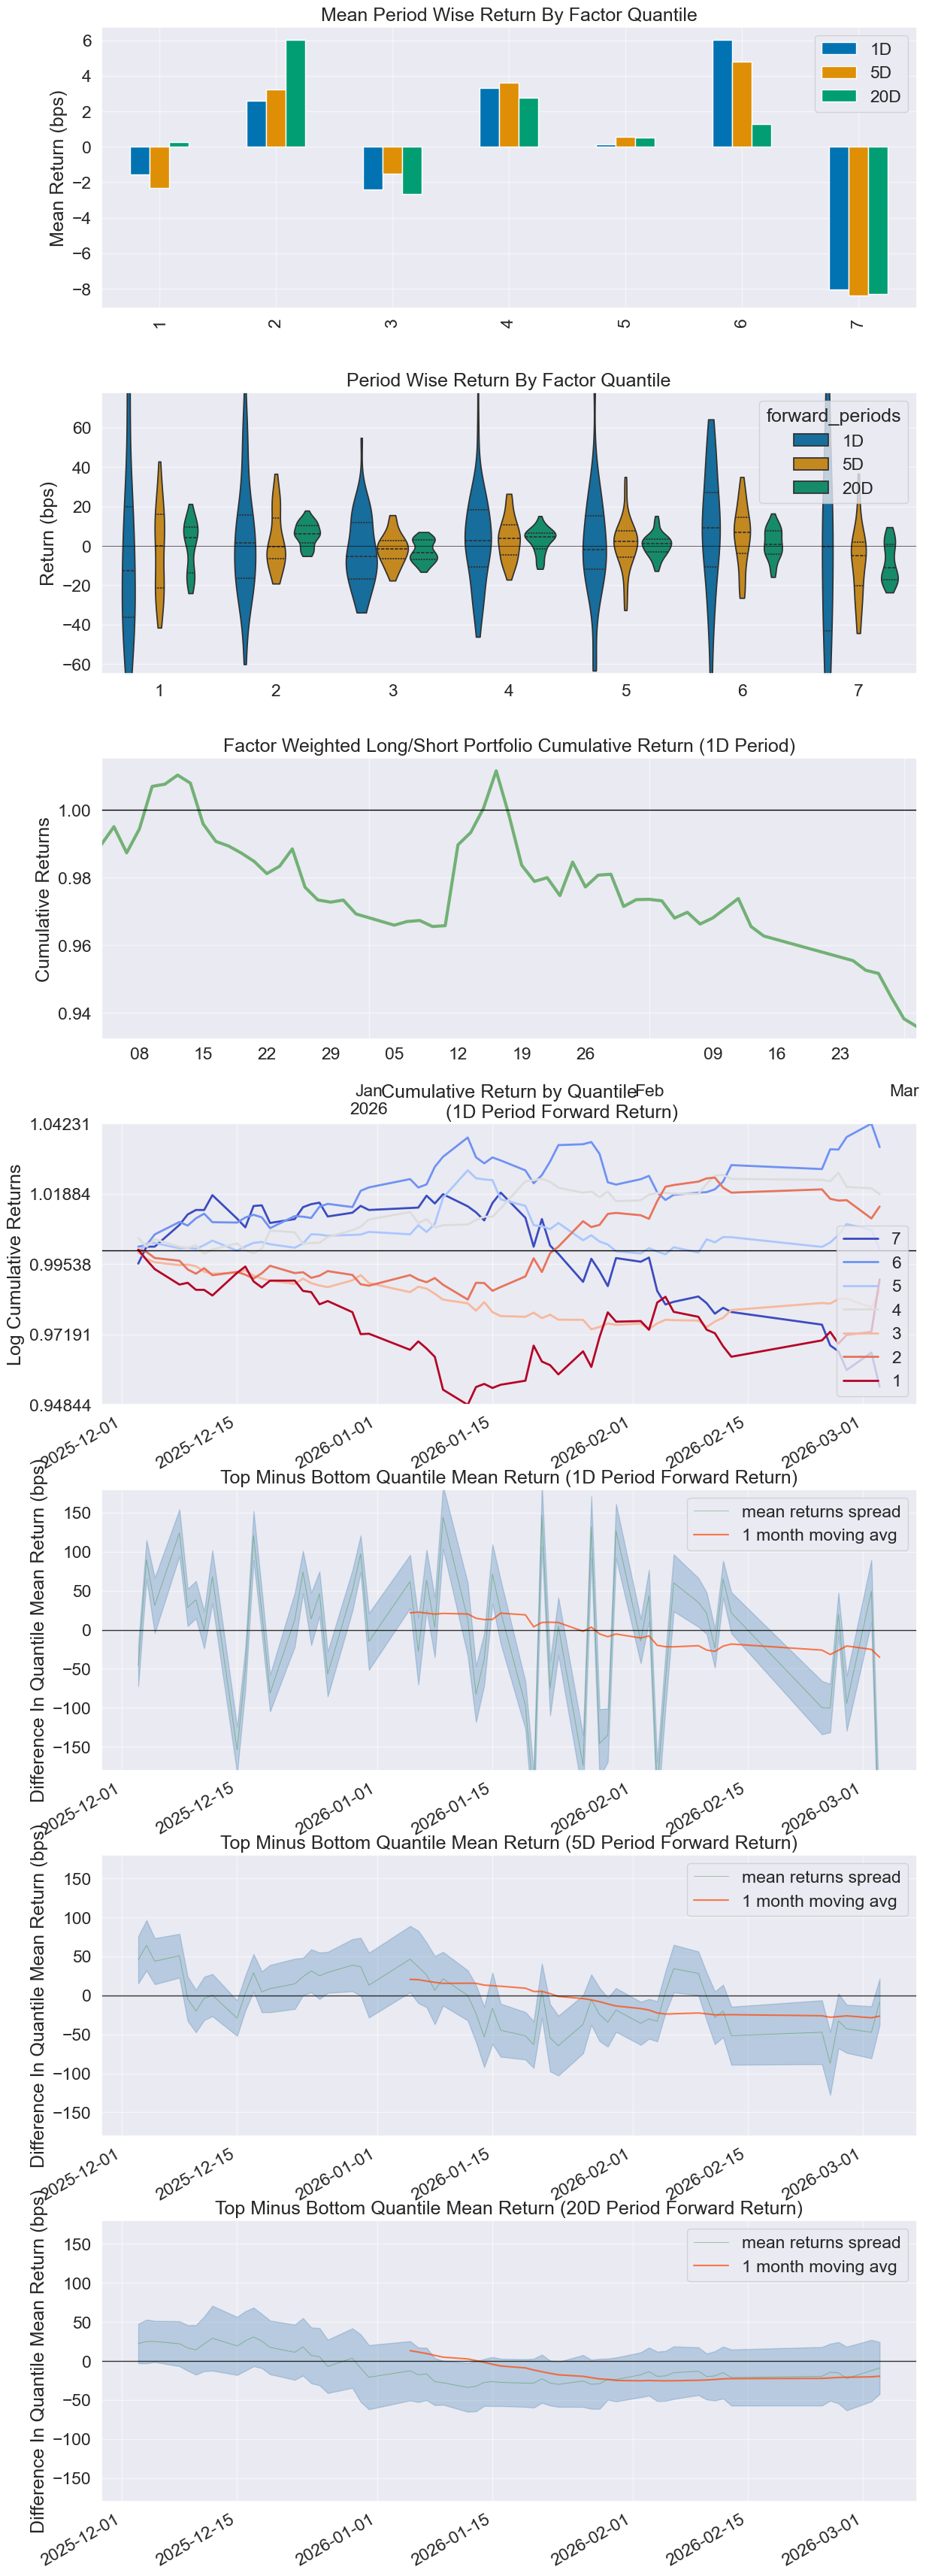

Information Analysis


,1D,5D,20D
IC Mean,-0.004,-0.006,-0.044
IC Std.,0.110,0.108,0.129
Risk-Adjusted IC,-0.033,-0.054,-0.337
t-stat(IC),-0.250,-0.406,-2.547
p-value(IC),0.804,0.686,0.014
IC Skew,-0.498,0.056,0.607
IC Kurtosis,-0.481,-1.225,-1.258


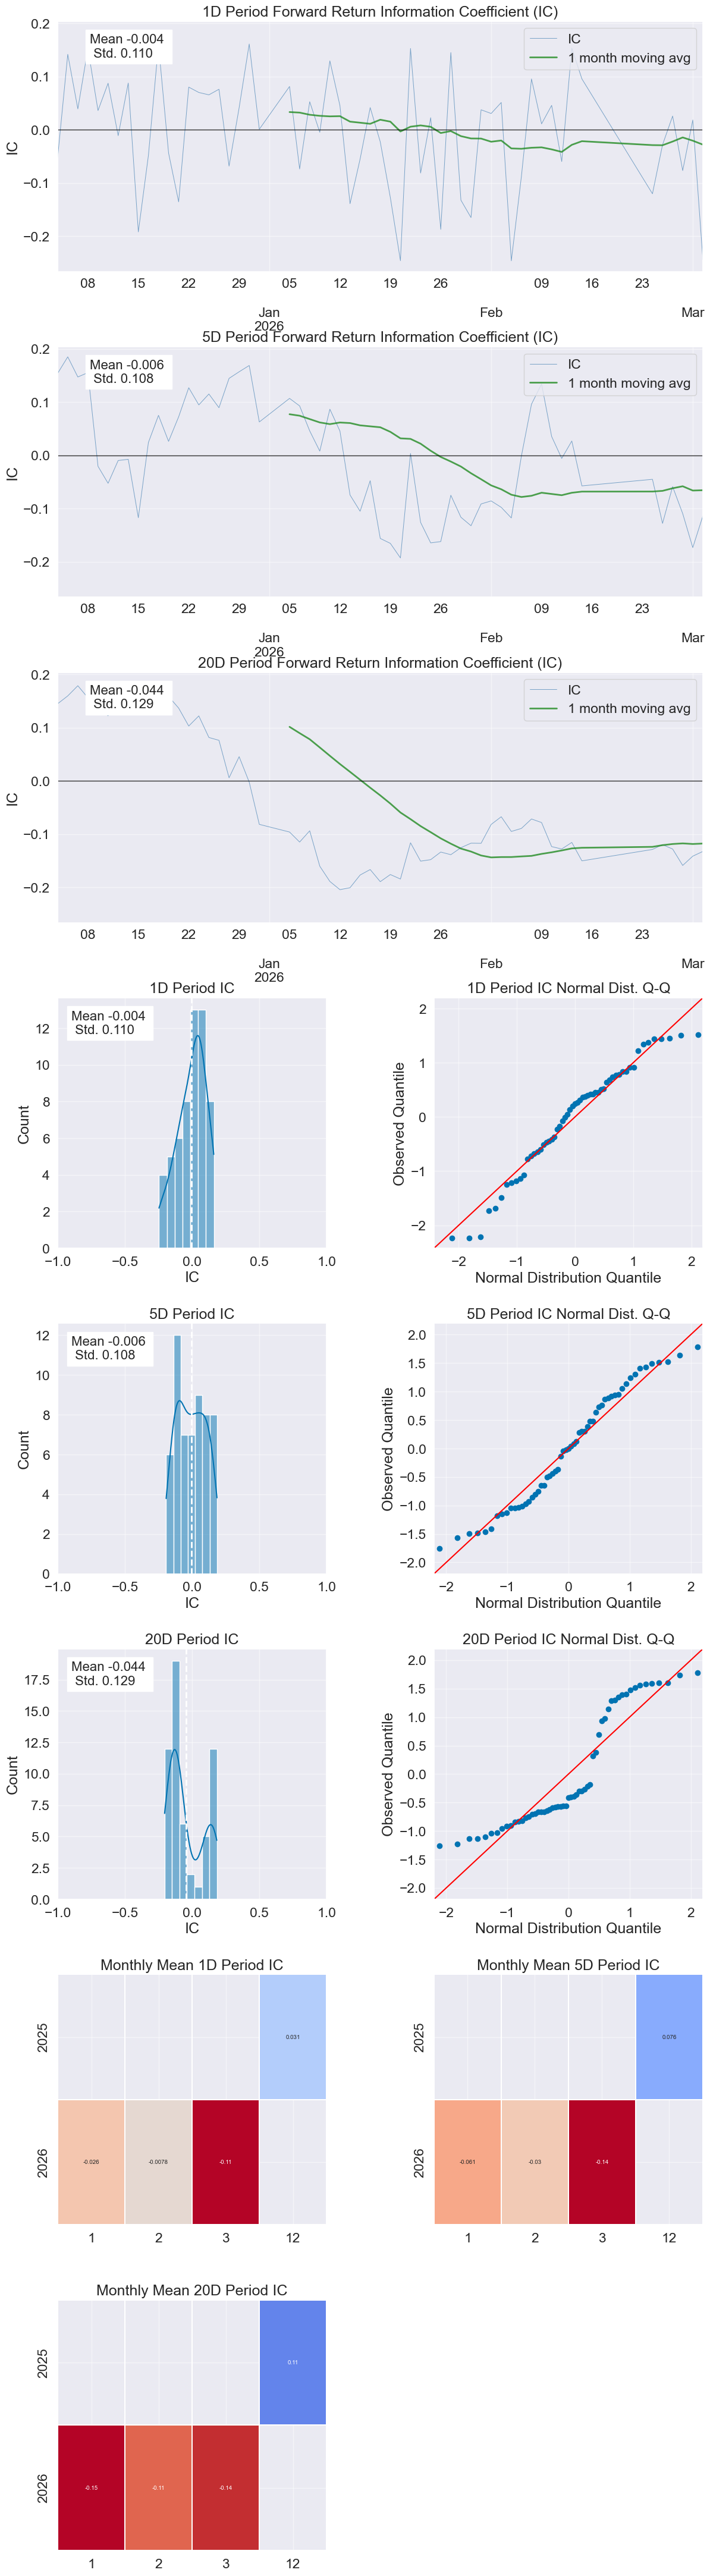

Turnover Analysis


,1D,5D,20D
Quantile 1 Mean Turnover,0.006,0.026,0.105
Quantile 2 Mean Turnover,0.012,0.052,0.198
Quantile 3 Mean Turnover,0.013,0.059,0.220
Quantile 4 Mean Turnover,0.015,0.070,0.256
Quantile 5 Mean Turnover,0.016,0.071,0.259
Quantile 6 Mean Turnover,0.014,0.059,0.218
Quantile 7 Mean Turnover,0.008,0.037,0.160


,1D,5D,20D
Mean Factor Rank Autocorrelation,1.0,1.0,0.995


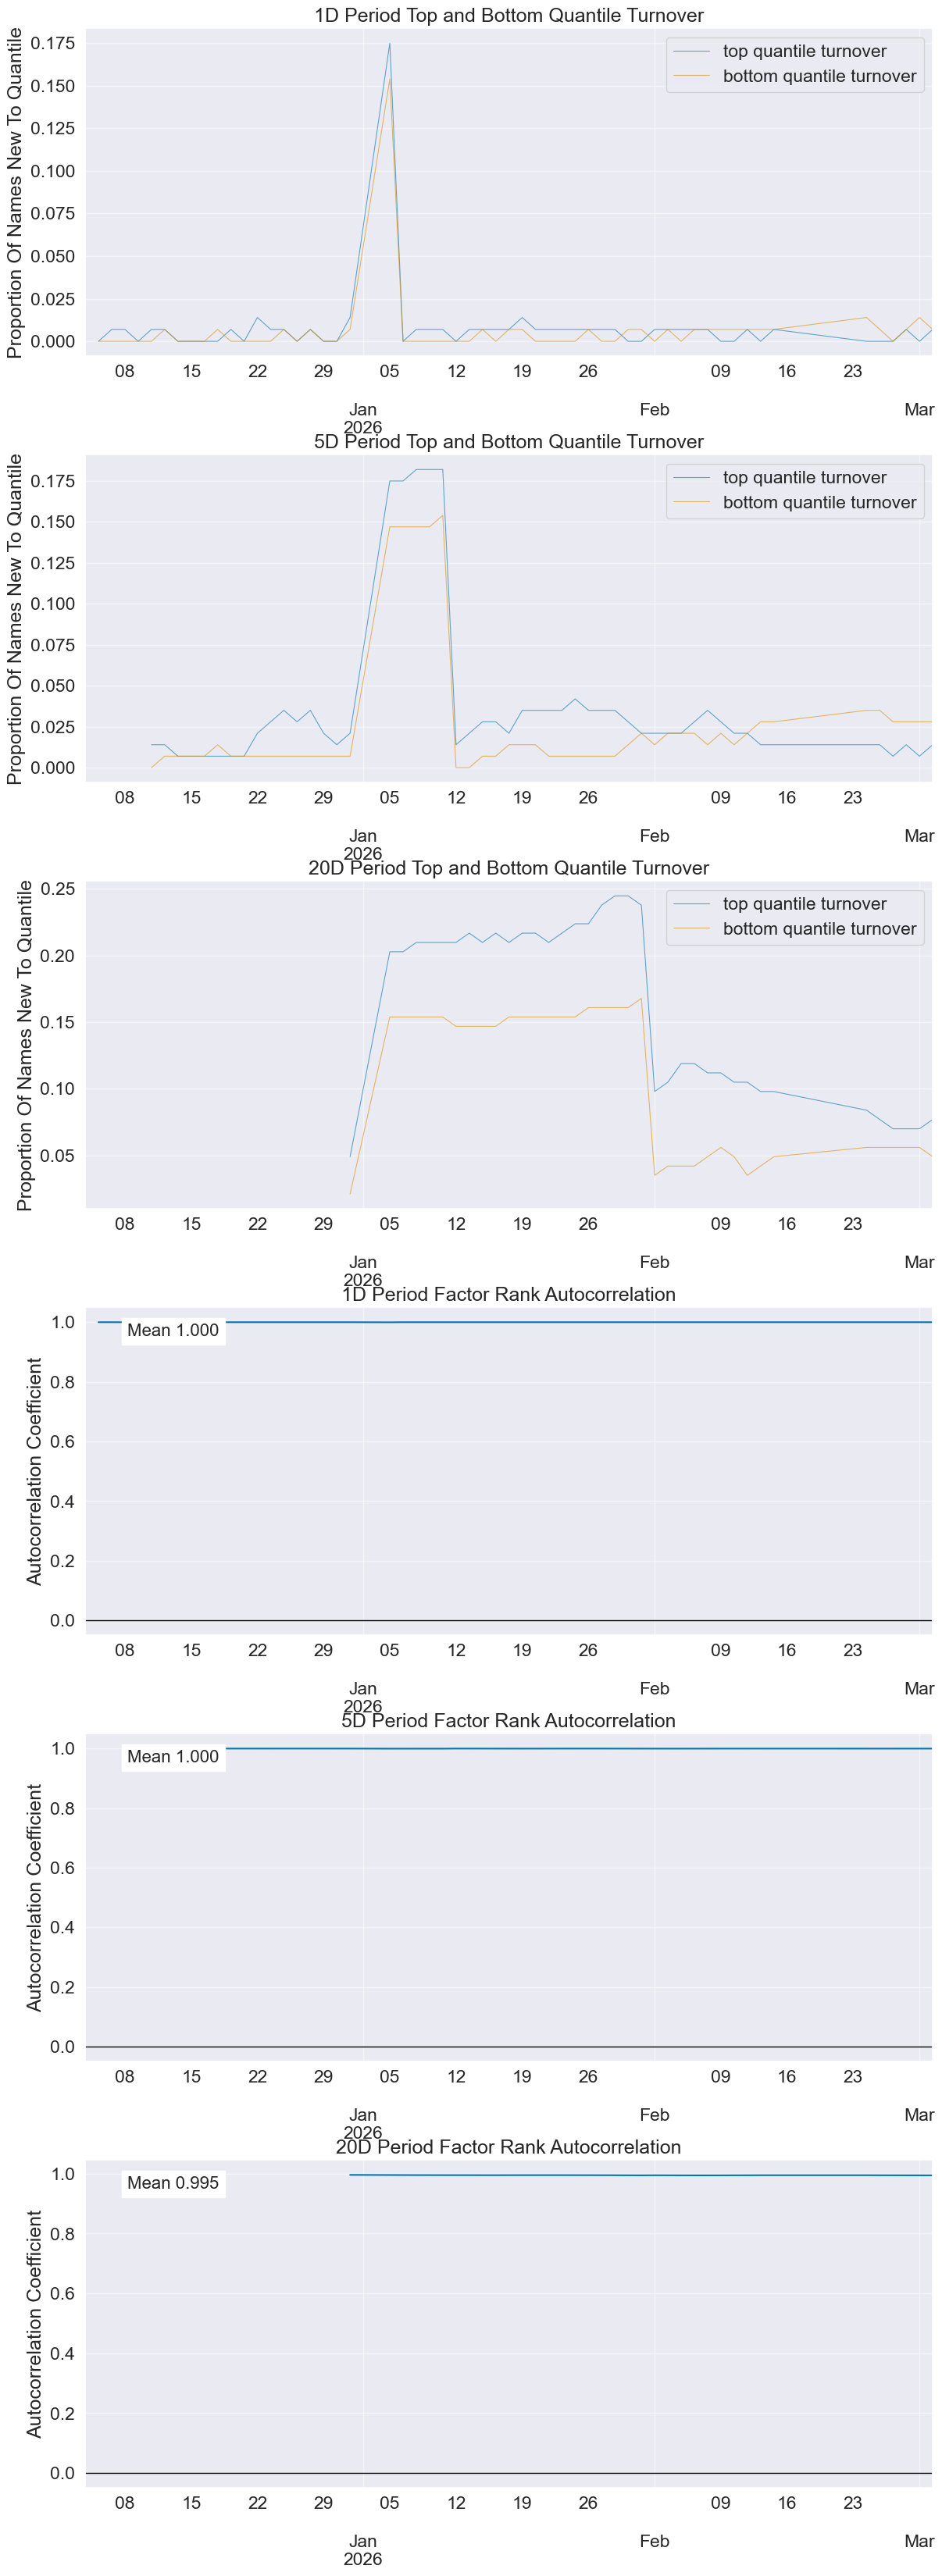

In [85]:
# 调用alphalens进行因子评估
al.tears.create_full_tear_sheet(
    factor_data=factor_data,
    long_short=True,
    group_neutral=False,
    by_group=False
)